In [3]:
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(".."))

In [5]:
from src.preprocess import load_data, split_data, build_preprocessor
from src.train import get_models, train_and_evaluate
from src.predict import predict_and_save

In [7]:
train, test, test_ids = load_data(
    "../data/training.csv",
    "../data/test.csv"
)


X_train, X_val, y_train, y_val = split_data(train)

preprocessor = build_preprocessor(X_train)

models = get_models()

best_model, results = train_and_evaluate(
    models, preprocessor, X_train, X_val, y_train, y_val
)

logistic AUC: 0.7139
rf AUC: 0.8353
gb AUC: 0.8676


/Users/mriganavdas/opt/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:36:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


xgb AUC: 0.8691


In [9]:
predict_and_save(
    best_model,
    test,
    test_ids,
    "../outputs/test_probabilities.csv"
)

Predictions saved to: ../outputs/test_probabilities.csv


In [10]:
# Extract components from pipeline
preprocessor = best_model.named_steps['preprocessor']
model = best_model.named_steps['model']

In [11]:
X_val_transformed = preprocessor.transform(X_val)

In [13]:
feature_names = X_train.columns

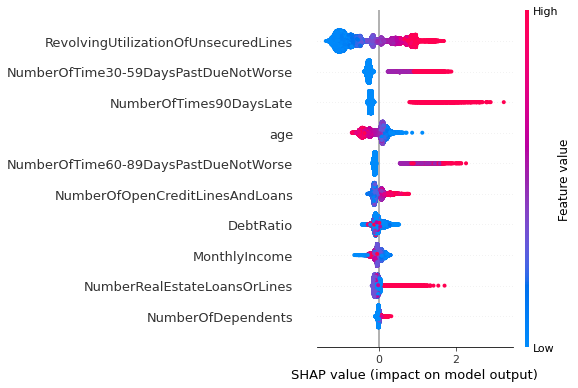

In [14]:
preprocessor = best_model.named_steps["preprocessor"]
model = best_model.named_steps["model"]

X_val_transformed = preprocessor.transform(X_val)
feature_names = X_val.columns

import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val_transformed)

shap.summary_plot(
    shap_values,
    X_val_transformed,
    feature_names=feature_names
)

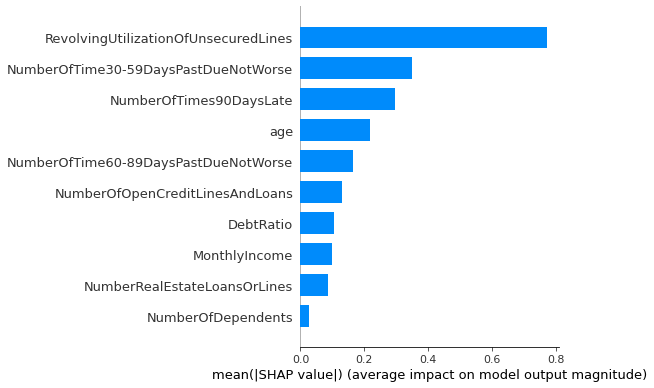

In [15]:
shap.summary_plot(
    shap_values,
    X_val_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

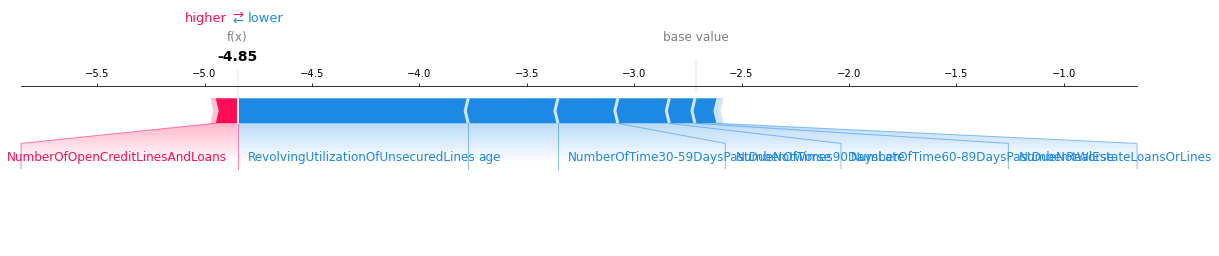

In [16]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    feature_names=feature_names,
    matplotlib=True
)

In [17]:
from sklearn.model_selection import GridSearchCV

In [18]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

In [19]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 4, 5],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

In [20]:
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 72 candidates, totalling 216 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         SimpleImputer(strategy='median'),
                                                                         Index(['RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberO...
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                         

In [21]:
best_model = grid_search.best_estimator_

print("Best Params:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best Score: 0.8641408222255275


In [22]:
from sklearn.metrics import roc_auc_score

probs = best_model.predict_proba(X_val)[:,1]
auc = roc_auc_score(y_val, probs)

print("Validation AUC:", auc)

Validation AUC: 0.8690528189260729


In [23]:
best_model = grid_search.best_estimator_

In [24]:
preprocessor = best_model.named_steps["preprocessor"]
model = best_model.named_steps["model"]

In [25]:
X_val_transformed = preprocessor.transform(X_val)
feature_names = list(X_val.columns)

In [26]:
feature_names = list(X_val.columns)

In [27]:
import shap

explainer = shap.TreeExplainer(model)

In [28]:
X_sample = X_val_transformed[:1000]

shap_values = explainer.shap_values(X_sample)

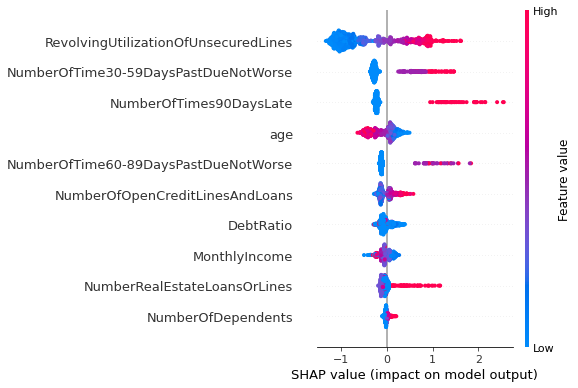

In [29]:
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names
)

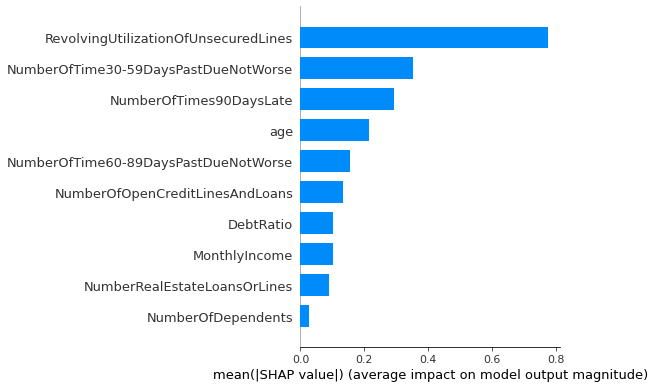

In [30]:
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    plot_type="bar"
)

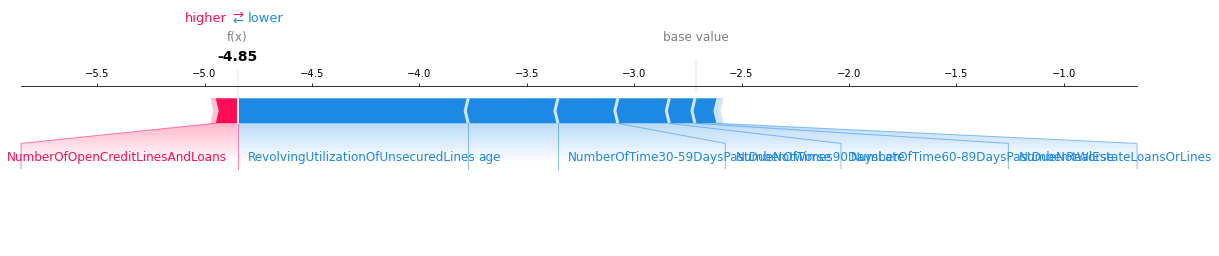

In [31]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    feature_names=feature_names,
    matplotlib=True
)